## Robust Ambulance Relocation
### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import rsome as rso

from rsome import ro
from rsome import grb_solver as grb
from multiprocess import Pool

## Functions
### Create regions and connections

In [4]:
def reg_connect(J, C, random_state=None):
    """
    The function reg_connect() construct the regions for the ambulance
    service.

    Parameters
    ----------
    J : int
        Number of regions to serve.
    C : int
        Minimum umber of neighboring regions can be served.
    random_state : int
        The seed for the random number generator.

    Returns
    -------
    pos : a 2-D array of two columns
        The X and Y coordinates of regions.
    cnt : a 2-D array of two columns
        The from index and to index of region connections.
    """

    if random_state is not None:
        np.random.seed(random_state)

    pos = np.random.rand(J, 2)
    d2 = (pos[:, 0] - pos[:, 0][:, None])**2 + (pos[:, 1] - pos[:, 1][:, None])**2

    Jidx = np.argsort(d2, axis=0)[1:C+1]
    Jmat = np.zeros((J, J)).astype(bool)
    for j in range(J):
        Jmat[j, Jidx[:, j]] = True

    cnt = np.array(np.where(Jmat | Jmat.T)).T

    return pos, cnt

### Random sampling of demand

In [6]:
def rand_demand(lam, offset, size, random_state=None):
    """
    The function rand_demand() generates random samples for the demand of
    ambulance service. It is a Poisson distributted random variable plus an
    integer offset.

    Parmaters
    ---------
    lam : np.ndarray
        A 2D array of lambda values of Poisson distributted random demand.
    offset : int or arrays of integers
        A ffixed offset of the demand.
    size : int
        Sample size of randomly generated demand.

    Returns
    -------
    out : numpy.ndarray
        An array that has the dimension to be (S, T, J).
    """

    if random_state is not None:
        np.random.seed(random_state)

    T, J = lam.shape

    return offset + np.random.poisson(lam=lam, size=(size, T, J))

### Centroids and deviations

The centroids and deviations of the random demand are estimated according to the optimization problem (30), and the solution is achieved following *THEOREM 4*. 

In [8]:
def dev_metric(zsmp):
    """
    The dev_metric() function estimate the distribution parameters according
    to Theorem 4.

    Parameters
    ----------
    zsmp : np.ndarray
        An array representing the random samples of the ambulance demand. The dimension
        of the array is (S, T, J), where S is the sample size, T is the number of periods,
        and J is the number of regions.

    Returns
    -------
    zhat : np.ndarray
        The centroid value of the demand samples.
    sigma_over : np.ndarray
        The positive-side deviation of the demand samples.
    sigma_under : np.ndarray
        The negative-side deviation of the demand samples.
    """

    S = zsmp.shape[0]

    zs_2d = zsmp.reshape((S, -1))
    dev = (zs_2d - zs_2d.reshape((S, 1, -1)))
    total_dev = np.sqrt(np.maximum(dev, 0).mean(axis=0)) + np.sqrt(np.maximum(-dev, 0).mean(axis=0))
    index = np.argmin(total_dev, axis=0)
    zhat = zs_2d[index, range(zsmp.size // S)].reshape(zsmp.shape[1:])

    dev_over = np.sqrt(np.maximum(zsmp - zhat, 0).mean(axis=0))
    dev_under = np.sqrt(np.maximum(zhat - zsmp, 0).mean(axis=0))
    sigma_over = (dev_over + dev_under) * dev_over
    sigma_under = (dev_over + dev_under) * dev_under

    return zhat, sigma_over, sigma_under

The demand samples and their deviation parameters are displayed by the following function.

In [10]:
def plot_devs(zsmp, zhat, sigma_over, sigma_under):
    """
    The plot_devs() function plots the samples of the ambulance demand and
    the estiamted parameters in terms of 1) the centroid values zhat; 2) the
    positive-side deviation sigma_over; and 3) the negative-side deviation
    sigma_under.

    Parameters
    ----------
    zsmp : np.ndarray
        An array representing the random samples of the ambulance demand. The dimension
        of the array is (S, T, J), where S is the sample size, T is the number of periods,
        and J is the number of regions.
    zhat : np.ndarray
        The centroid value of the demand samples.
    sigma_over : np.ndarray
        The positive-side deviation of the demand samples.
    sigma_under : np.ndarray
        The negative-side deviation of the demand samples.

    Notes
    -----
    The deviations are increased proportionally to better display their values.
    """

    S, T, J = zsmp.shape

    fig, ax = plt.subplots(J, 1, figsize=(5, 1.8*J))
    xdata = np.arange(1, T+1)
    for j in range(J):
        errs = 2 * np.concat((sigma_under[:, j][None, :], sigma_over[:, j][None, :]))
        ax[j].plot(xdata, zsmp[:, :, j].T, color='k', alpha=0.05)
        ax[j].errorbar(xdata, zhat[:, j], yerr=errs,
                       marker='.', color='b')

        ax[j].grid()
        ax[j].set_ylabel(f"R{j+1}")

    ax[-1].set_xlabel("Period")
    plt.show()

### Formulations
#### Minimum Gamma model

In [12]:
def sto_min_Gamma(params, sample, display=True):
    """
    The function sto_min_Gamma() finds the minimum value of Gamma (the total number
    of ambulances) such that there is no constraint violation for the in-sample demand
    records.

    Parameters
    ----------
    params : dict
        A dictionary that summarizes system parameters and in-sample data for demand.
    sample : dict
        A dictionary that summarizes demand sample information, including the sample
        records, estimated parameters, etc.
    display : bool
        If the solution log is displayed or not.

    Return
    ------
    Gamma : float
        The minimum number of ambulances such that there is no unserved demand or constraint
        violation under the in-sample data.
    """

    Iout, Iin = params['Iout'], params['Iin']
    zin = sample['zin']

    Sin, T, J = zin.shape
    L = Iout.shape[0]

    model = ro.Model()

    x = model.dvar(J, vtype='I')
    r = model.dvar((T-1, len(cnt)))

    model.min(x.sum())

    xt = x
    for t in range(T-1):
        rout = r[t] @ Iout
        rin = r[t] @ Iin

        model.st(r[t] @ Iout <= xt)
        model.st(0 >= zin[:, t] - xt + rout)

        xt = xt - rout + rin

    model.st(0 >= zin[:, -1] - xt)
    model.st(x >= 0, r >= 0)

    model.solve(grb, params={"OutputFlag": 0}, display=display)

    return model.get()

#### Stochastic optimization model

In [14]:
def sto_model(params, sample, display=True):
    """
    The function sto_model() formulates a two-stage stochastic optimization model and
    solves the optimal ambulance allocations based on the in-sample demands.

    Parameters
    ----------
    params : dict
        A dictionary that summarizes system parameters and in-sample data for demand.
    sample : dict
        A dictionary that summarizes demand sample information, including the sample
        records, estimated parameters, etc.
    display : bool
        If the solution log is displayed or not.

    Returns
    -------
    xs : np.ndarray
        The solution in terms of the ambulance allocation in the current period.
    model : rsome.ro.Model
        The model object
    """

    Iout, Iin, Gamma = params['Iout'], params['Iin'], params['Gamma']
    zin = sample['zin']

    Sin, T, J = zin.shape
    L = Iout.shape[0]

    model = ro.Model()

    x = model.dvar(J, vtype='I')
    r = model.dvar((T-1, L))
    v = model.dvar((Sin, 1))

    model.min(v.sum() * (1/Sin))
    model.st(x.sum() == Gamma)

    xt, rout, rin = x, r@Iout, r@Iin
    for t in range(T-1):
        model.st(rout[t] <= xt)
        model.st(v >= zin[:, t] - xt + rout[t])
        xt = xt - rout[t] + rin[t]
    model.st(v >= zin[:, -1] - xt)
    model.st(x >= 0, r >= 0)

    model.solve(grb, display=display)
    if display:
        print(model.get())

    return x.get(), model

#### Scenario-based worst-case model

In [16]:
def saa_model(params, sample, display=True):
    """
    The function saa_model() formulates a two-stage stochastic optimization model with
    a sample average approximated object of the expected loss. It solves the optimal
    ambulance allocations based on the in-sample demands.

    Parameters
    ----------
    params : dict
        A dictionary that summarizes system parameters and in-sample data for demand.
    sample : dict
        A dictionary that summarizes demand sample information, including the sample
        records, estimated parameters, etc.
    display : bool
        If the solution log is displayed or not.

    Returns
    -------
    xs : np.ndarray
        The solution in terms of the ambulance allocation in the current period.
    model : rsome.ro.Model
        The model object
    """

    Iout, Iin, Gamma = params['Iout'], params['Iin'], params['Gamma']
    zin = sample['zin']

    Sin, T, J = zin.shape
    L = Iout.shape[0]

    model = ro.Model()

    x = model.dvar(J, vtype='I')
    r = model.dvar((T-1, L))
    u = model.dvar((Sin, T, J))

    model.min(u.sum() *(1/Sin))
    model.st(x.sum() == Gamma)

    xt, rout, rin = x, r@Iout, r@Iin
    for t in range(T-1):
        model.st(rout[t] <= xt)
        model.st(u[:, t] >= zin[:, t] - xt + rout[t])
        xt = xt - rout[t] + rin[t]
    model.st(u[:, -1] >= zin[:, -1] - xt)
    model.st(x >= 0, r >= 0, u >= 0)

    model.solve(grb, display=display)
    if display:
        print(model.get())

    return x.get(), model

#### Robust Satisficing model

In [18]:
# one kappa
def rs_model(params, sample, gamma=None, display=True):
    """
    The function rs_model() formulates a multi-stage robust satisficing model and
    solves the optimal ambulance allocations based on the estimated deviation
    parameters of demand.

    Parameters
    ----------
    params : dict
        A dictionary that summarizes system parameters and in-sample data for demand.
    sample : dict
        A dictionary that summarizes demand sample information, including the sample
        records, estimated parameters, etc.
    gamma : NoneType or float
        The radius parameter of the uncertainty set. If it is None (default value), then
        the radius parameter goes to infinity.
    display : bool
        If the solution log is displayed or not.

    Returns
    -------
    xs : np.ndarray
        The solution in terms of the ambulance allocation in the current period.
    model : rsome.ro.Model
        The model object
    """

    Iout, Iin, Gamma = params['Iout'], params['Iin'], params['Gamma']
    zhat, sigma_over, sigma_under = sample['zhat'], sample['sigma_over'], sample['sigma_under']

    T, J = zhat.shape
    L = Iout.shape[0]

    model = ro.Model()

    z = model.rvar((T, J))
    w_over = model.rvar((T, J))
    w_under = model.rvar((T, J))
    rho = model.rvar()     # the u in the uncertainty set

    uset = [
        w_over - w_under == z - zhat,
        (w_over*(1/sigma_over) + w_under*(1/sigma_under)).sum() <= rho,
        w_over >= 0, w_under >= 0,
    ]
    if gamma is not None:
        uset.append(rho <= gamma)

    k = model.dvar()
    x = model.dvar(J, vtype='I')
    r = model.ldr((T-1, len(cnt)))

    for t in range(T-1):
        r[t].adapt(w_over[:t+1])
        r[t].adapt(w_under[:t+1])

    model.minmax(k, uset)
    model.st(x.sum() == Gamma)

    xt, rout, rin = x, r@Iout, r@Iin
    for t in range(T-1):
        model.st(rout[t] <= xt + k*rho)
        model.st(k*rho >= z[t] - xt + rout[t])
        xt = xt - rout[t] + rin[t]
    model.st(k*rho >= z[-1] - xt)
    model.st(x >= 0, k >= 0)
    model.st(r >= - k*rho)

    model.solve(grb, display=display)

    return x.get(), model

### Simulation

#### Simulation for one demand sample

In [20]:
def one_sim_pi(params, xs, zs, plot=False):
    """
    The function one_sim_pi() formulates a perfect information model to solve future
    allocation of ambulance assuming the future demand is realized. The result is used
    in simulations to evaluate the performance of the current allocation decision.

    Parameters
    ----------
    params : dict
        A dictionary that summarizes system parameters and in-sample data for demand.
    xs : np.ndarray
        An array representing the allocation of ambulance in the current time step.
    zs : 2D array
        An array of realized demand.
    plot : bool
        If the perfect information allocation and the realized demand are visualized.

    Returns
    -------
    output : float
        The total unserved demand under the realized demand.
    """

    Iout, Iin = params['Iout'], params['Iin']

    L = Iout.shape[0]
    T, J = zs.shape

    model = ro.Model()
    xa = model.dvar((T, J), vtype='I')
    ra = model.dvar((T-1, L))
    u = model.dvar((T, J))

    model.min(u.sum())
    model.st(
        xa[0] == xs,
        xa[1:] == xa[:-1] - ra@Iout  + ra@Iin,
        xa[:-1] >= ra@Iout,
        xa >= 0, ra >= 0,
        u[:-1] >= zs[:-1] - xa[:-1] + ra@Iout,
        u[-1] >= zs[-1] - xa[-1],
        u >= 0
    )

    model.solve(grb, display=False)

    return u.get().sum()

#### Parallel simulation of samples

In [22]:
def rar_sim(params, xs, zsim, n_jobs):
    """
    The function rar_sim() is used to conduct simulations to evaluate the performance
    of the current allocation decision under the demand samples.

    Parameters
    ----------
    params : dict
        A dictionary that summarizes system parameters and in-sample data for demand.
    xs : np.ndarray
        An array representing the allocation of ambulance in the current time step.
    zsim : 3D array
        An array of demand samples used for the simulation.
    n_jobs : int
        The simulation is conducted parallelly, where the parameter is used to configure
        the number of threads running concurrently.

    Returns
    -------
    results : list
        A list of unserved demand under the given demand samples.
    """

    with Pool(n_jobs) as pr:
        ps = [[params, xs, zs, False] for zs in zsim]
        results = pr.starmap(one_sim_pi, ps)

    return results

## Experiments
### Parameters and experiment settings

In the following experiments, we address the ambulance reallocation problem over $T=5$ periods across $J=10$ regions. The geographic locations of these regions are randomly generated according to a uniform distribution, as illustrated in the figure below. Each region is assumed to be connected to at least two of its nearest neighboring regions. Ambulance fleets can only be reallocated between regions if a direct connection exists between them.

We assume that each random demand $\tilde{z}_{ti}$ is independent and defined as follows:

\begin{align}
\tilde{z}_{ti} = a_{ti} + \tilde{b}_{it} &&\forall i\in[J], t\in[T]
\end{align}

where $a_{ti}$ is a fixed integer randomly selected between 0 and 50, and $\tilde{b}_{it}$ is a Poisson-distributed random variable with mean $\lambda_{it}$ that is randomly generated between 20 and 150. To represent uncertain demand, we generate in-sample data sets with sample sizes of 100, 200, 500, and 1000. Additionally, an out-of-sample data set containing 20,000 records is used to evaluate the performance of the reallocation decisions. To serve the demand, the total number of available ambulances is set to be $\Gamma=1650$. 

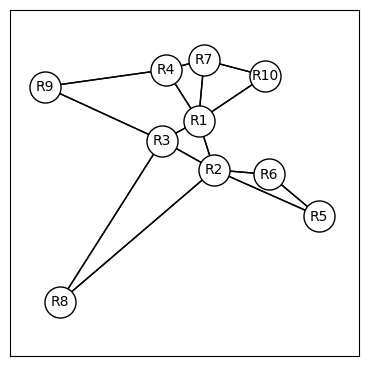

In [24]:
T, J = 5, 10            # Numbers of periods and regions
C = 2                   # Minimum umber of neighboring regions that are connected

np.random.seed(0)
pos, cnt = reg_connect(J, C)

plt.figure(figsize=(4.5, 4.5))
for j in range(J):
    plt.text(pos[j, 0], pos[j, 1], f'R{j+1}', ha='center', va='center')
for c in cnt:
    plt.plot([pos[c[0], 0], pos[c[1], 0]], [pos[c[0], 1], pos[c[1], 1]], c='k', linewidth=1, zorder=1)
plt.scatter(pos[:, 0], pos[:, 1], s=500, edgecolor='k', facecolor='w', zorder=2)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.xticks([])
plt.yticks([])
plt.show()

In [25]:
lam = np.random.uniform(20, 150, size=(T, J))
offset = np.random.randint(0, 51, size=(T, J))

samples = {}
for S in [100, 200, 500, 1000]:
    zin = rand_demand(lam, offset, size=S)
    zhat, sigma_over, sigma_under = dev_metric(zin)
    samples[S] = dict(zin=zin, zhat=zhat,
                      sigma_over=sigma_over, sigma_under=sigma_under)

zout = rand_demand(lam, offset, size=20000)

In [26]:
Iout = np.zeros((len(cnt), J))
Iout[np.arange(len(cnt)), cnt[:, 0]] = 1
Iin = np.zeros((len(cnt), J))
Iin[np.arange(len(cnt)), cnt[:, 1]] = 1

params = dict(Iout=Iout, Iin=Iin)
Gamma = (sto_min_Gamma(params, samples[1000]) - J*20) // 10 * 10
params['Gamma'] = Gamma
print(f'Gamma = {Gamma}')

Set parameter Username
Set parameter LicenseID to value 2775606
Academic license - for non-commercial use only - expires 2027-02-05
Being solved by Gurobi...
Solution status: 2
Running time: 0.2630s
Gamma = 1650.0


In [27]:
results = {}
times = {}
for Sin, sample in samples.items():
    print(f'Sample size = {Sin}')

    result = pd.DataFrame({})
    time = {}

    x_sto, model_sto = sto_model(params, sample, display=False)
    result['SO'] = rar_sim(params, x_sto, zout, n_jobs=10)
    time['SO'] = model_sto.solution.time
    print('▮', end='')

    x_saa, model_saa = saa_model(params, sample, display=False)
    result['SAA'] = rar_sim(params, x_saa, zout, n_jobs=10)
    time['SAA'] = model_saa.solution.time
    print('▮', end='')

    gammas = np.linspace(1, 7, 13)
    for gamma in gammas:
        x_rs, model_rs = rs_model(params, sample, gamma, display=False)
        result[f'RS_{gamma}'] = rar_sim(params, x_rs, zout, n_jobs=10)
        time[f'RS_{gamma}'] = model_rs.solution.time
        print('▮', end='')

    results[Sin] = result
    times[Sin] = time

    print('\n--------------------------------------------------')
    print(f'SO Model:  {result["SO"].mean():08.5f}')
    print(f'SAA Model: {result["SAA"].mean():08.5f}')
    print(f'RS Model:  {result.loc[:, "RS_1.0":].mean().min():08.5f}')
    print('--------------------------------------------------\n')

Sample size = 100
▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
--------------------------------------------------
SO Model:  01.39765
SAA Model: 01.50965
RS Model:  00.20765
--------------------------------------------------

Sample size = 200
▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
--------------------------------------------------
SO Model:  01.73395
SAA Model: 01.53230
RS Model:  00.20510
--------------------------------------------------

Sample size = 500
▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
--------------------------------------------------
SO Model:  01.49300
SAA Model: 01.55665
RS Model:  00.14710
--------------------------------------------------

Sample size = 1000
▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
--------------------------------------------------
SO Model:  01.53195
SAA Model: 01.53395
RS Model:  00.18930
--------------------------------------------------



Here are the results for the 500-record in-sample data set. 

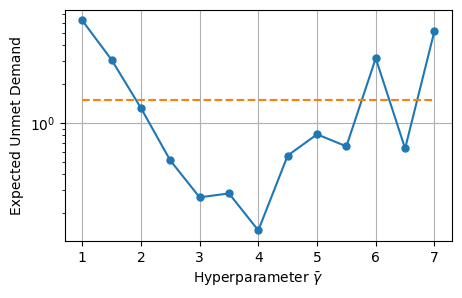

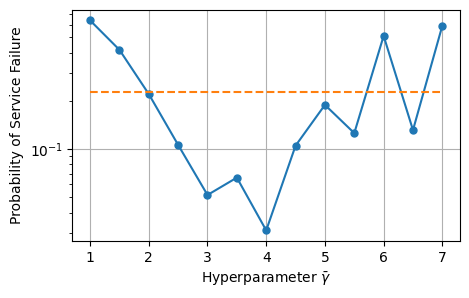

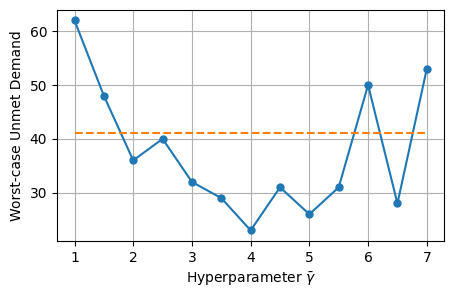

In [29]:
Sin = 500

plt.figure(figsize=(5, 3))
plt.plot(gammas, results[Sin].loc[:, 'RS_1.0':].mean(), marker='o', markersize=5, label='Satisficing Model')
plt.plot([gammas[0], gammas[-1]], [results[Sin]['SO'].mean()]*2, linestyle='--', label='Stochastic Model')
plt.xlabel(r'Hyperparameter $\bar{\gamma}$')
plt.ylabel('Expected Unmet Demand')
plt.yscale('log')
plt.grid()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(gammas, (results[Sin].loc[:, 'RS_1.0':] > 1e-3).mean(), marker='o', markersize=5, label='Satisficing Model')
plt.plot([gammas[0], gammas[-1]], [(results[Sin]['SO'] > 1e-3).mean()]*2, linestyle='--', label='Stochastic Model')
plt.xlabel(r'Hyperparameter $\bar{\gamma}$')
plt.ylabel('Probability of Service Failure')
plt.yscale('log')
plt.grid()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(gammas, results[Sin].loc[:, 'RS_1.0':].max(), marker='o', markersize=5, label='Satisficing Model')
plt.plot([gammas[0], gammas[-1]], [results[Sin]['SO'].max()]*2, linestyle='--', label='Stochastic Model')
plt.xlabel(r'Hyperparameter $\bar{\gamma}$')
plt.ylabel('Worst-case Unmet Demand')
plt.grid()
plt.show()

The results for different samples are provided below.

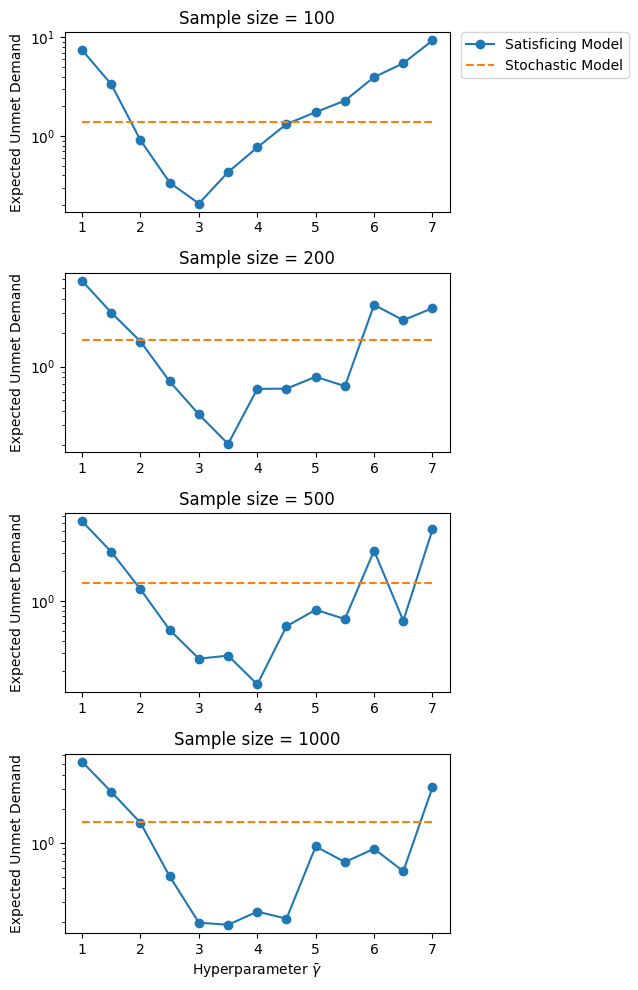

In [31]:
fig, axes = plt.subplots(4, 1, figsize=(6.5, 10))

axes[0].plot(gammas, results[100].loc[:, 'RS_1.0':].mean(), marker='o', label='Satisficing Model')
axes[0].plot([gammas[0], gammas[-1]], [results[100]['SO'].mean()]*2, linestyle='--', label='Stochastic Model')
axes[0].set_title('Sample size = 100')
axes[0].set_ylabel('Expected Unmet Demand')
axes[0].set_yscale('log')

axes[1].plot(gammas, results[200].loc[:, 'RS_1.0':].mean(), marker='o', label='Satisficing Model')
axes[1].plot([gammas[0], gammas[-1]], [results[200]['SO'].mean()]*2, linestyle='--', label='Stochastic Model')
axes[1].set_title('Sample size = 200')
axes[1].set_ylabel('Expected Unmet Demand')
axes[1].set_yscale('log')

axes[2].plot(gammas, results[500].loc[:, 'RS_1.0':].mean(), marker='o', label='Satisficing Model')
axes[2].plot([gammas[0], gammas[-1]], [results[500]['SO'].mean()]*2, linestyle='--', label='Stochastic Model')
axes[2].set_title('Sample size = 500')
axes[2].set_ylabel('Expected Unmet Demand')
axes[2].set_yscale('log')

axes[3].plot(gammas, results[1000].loc[:, 'RS_1.0':].mean(), marker='o', label='Satisficing Model')
axes[3].plot([gammas[0], gammas[-1]], [results[1000]['SO'].mean()]*2, linestyle='--', label='Stochastic Model')
axes[3].set_title('Sample size = 1000')
axes[3].set_ylabel('Expected Unmet Demand')
axes[3].set_yscale('log')

axes[0].legend(bbox_to_anchor=(1.01, 1.04))
axes[3].set_xlabel(r'Hyperparameter $\bar{\gamma}$')
plt.tight_layout()
plt.show()

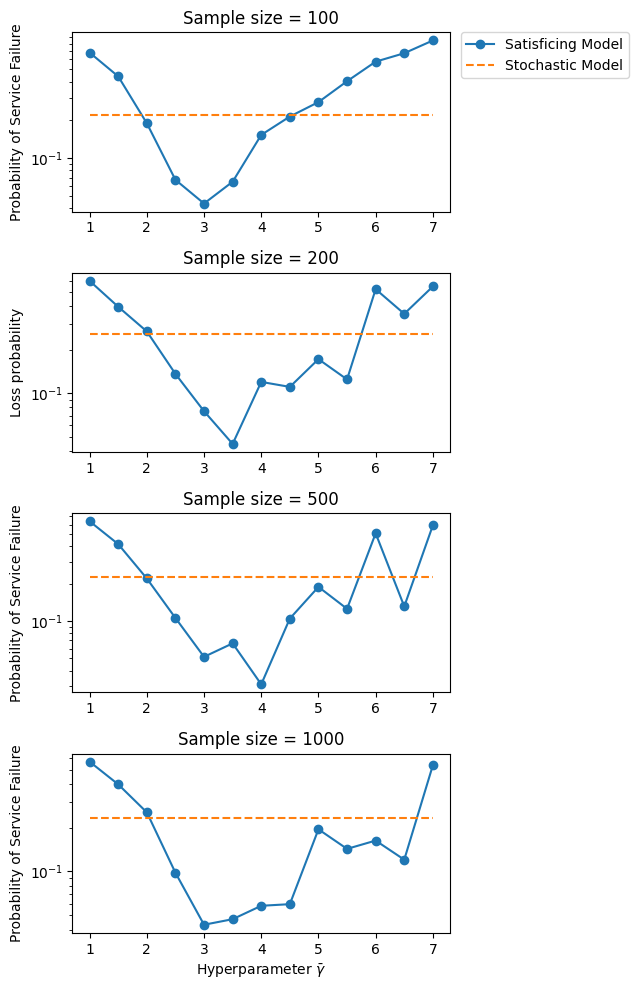

In [32]:
fig, axes = plt.subplots(4, 1, figsize=(6.5, 10))

axes[0].plot(gammas, (results[100].loc[:, 'RS_1.0':] > 1e-3).mean(), marker='o', label='Satisficing Model')
axes[0].plot([gammas[0], gammas[-1]], [(results[100]['SO'] > 1e-3).mean()]*2, linestyle='--', label='Stochastic Model')
axes[0].set_title('Sample size = 100')
axes[0].set_ylabel('Probability of Service Failure')
axes[0].set_yscale('log')

axes[1].plot(gammas, (results[200].loc[:, 'RS_1.0':] > 1e-3).mean(), marker='o', label='Satisficing Model')
axes[1].plot([gammas[0], gammas[-1]], [(results[200]['SO'] > 1e-3).mean() ]*2, linestyle='--', label='Stochastic Model')
axes[1].set_title('Sample size = 200')
axes[1].set_ylabel('Loss probability')
axes[1].set_yscale('log')

axes[2].plot(gammas, (results[500].loc[:, 'RS_1.0':] > 1e-3).mean(), marker='o', label='Satisficing Model')
axes[2].plot([gammas[0], gammas[-1]], [(results[500]['SO'] > 1e-3).mean()]*2, linestyle='--', label='Stochastic Model')
axes[2].set_title('Sample size = 500')
axes[2].set_ylabel('Probability of Service Failure')
axes[2].set_yscale('log')

axes[3].plot(gammas, (results[1000].loc[:, 'RS_1.0':] > 1e-3).mean(), marker='o', label='Satisficing Model')
axes[3].plot([gammas[0], gammas[-1]], [(results[1000]['SO'] > 1e-3).mean()]*2, linestyle='--', label='Stochastic Model')
axes[3].set_title('Sample size = 1000')
axes[3].set_ylabel('Probability of Service Failure')
axes[3].set_yscale('log')

axes[0].legend(bbox_to_anchor=(1.01, 1.04))
axes[3].set_xlabel(r'Hyperparameter $\bar{\gamma}$')
plt.tight_layout()
plt.show()

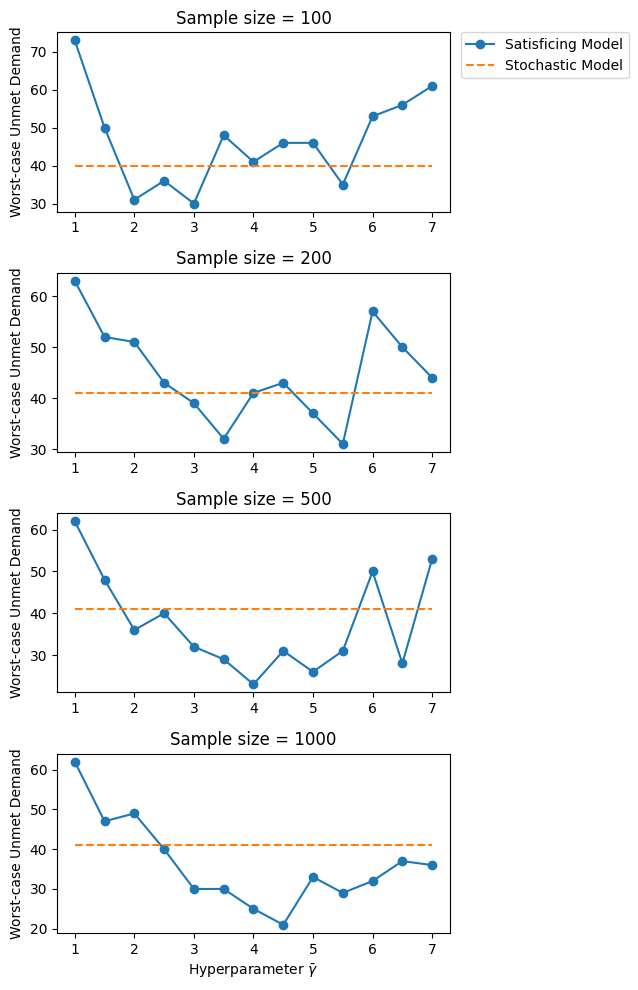

In [33]:
fig, axes = plt.subplots(4, 1, figsize=(6.5, 10))

axes[0].plot(gammas, results[100].loc[:, 'RS_1.0':].max(), marker='o', label='Satisficing Model')
axes[0].plot([gammas[0], gammas[-1]], [results[100]['SO'].max()]*2, linestyle='--', label='Stochastic Model')
axes[0].set_title('Sample size = 100')
axes[0].set_ylabel('Worst-case Unmet Demand')

axes[1].plot(gammas, results[200].loc[:, 'RS_1.0':].max(), marker='o', label='Satisficing Model')
axes[1].plot([gammas[0], gammas[-1]], [results[200]['SO'].max()]*2, linestyle='--', label='Stochastic Model')
axes[1].set_title('Sample size = 200')
axes[1].set_ylabel('Worst-case Unmet Demand')

axes[2].plot(gammas, results[500].loc[:, 'RS_1.0':].max(), marker='o', label='Satisficing Model')
axes[2].plot([gammas[0], gammas[-1]], [results[500]['SO'].max()]*2, linestyle='--', label='Stochastic Model')
axes[2].set_title('Sample size = 500')
axes[2].set_ylabel('Worst-case Unmet Demand')

axes[3].plot(gammas, results[1000].loc[:, 'RS_1.0':].max(), marker='o', label='Satisficing Model')
axes[3].plot([gammas[0], gammas[-1]], [results[1000]['SO'].max()]*2, linestyle='--', label='Stochastic Model')
axes[3].set_title('Sample size = 1000')
axes[3].set_ylabel('Worst-case Unmet Demand')

axes[0].legend(bbox_to_anchor=(1.01, 1.04), loc='upper left')
axes[3].set_xlabel(r'Hyperparameter $\bar{\gamma}$')
plt.tight_layout()
plt.show()

In [34]:
time_df = pd.DataFrame(times).T

pd.DataFrame([time_df.loc[:, 'RS_1.0':].mean(axis=1), time_df['SO']], index=['RS', 'SO'])

,100,200,500,1000
RS,0.658464,0.651058,0.608551,0.665878
SO,0.325353,0.944488,3.404627,8.324069


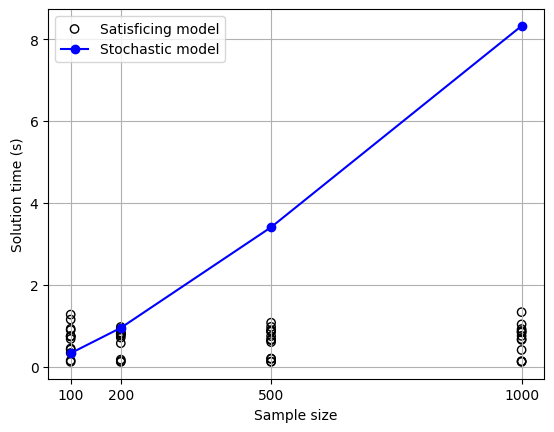

In [82]:

plt.scatter(np.array(time_df.index)[:, None] * np.ones((1, 13)), time_df.loc[:, 'RS_1.0':],
            edgecolor='k', facecolor='none', label='Satisficing model')
plt.plot(time_df.index, time_df['SO'], color='b', marker='o', label='Stochastic model')
plt.xticks(time_df.index, time_df.index)
plt.legend()
plt.xlabel('Sample size')
plt.ylabel('Solution time (s)')
plt.grid()
plt.show()